# Занятие 29. Переобучение и валидация

**Обобщение** (generalization) — способность модели давать хорошие прогнозы на **новых** объектах, которых не было при обучении.

Модель нужна не для запоминания таблицы, а для прогноза в будущем. Сегодня разберём, как отличить настоящую закономерность от удачного совпадения на известных данных и как **честно** сравнивать варианты моделей.

**Сквозной пример:** синтетическая регрессия $y \approx x^2$ с шумом; подбираем степень полинома (`PolynomialFeatures` + `LinearRegression`). Данные создаём в ячейке ниже и показываем на них **все** идеи занятия; сразу делим на train и validation.

К концу занятия вы сможете:

- объяснить разницу между train-, validation- и test-ошибкой;
- распознать недообучение и переобучение по двум кривым ошибки;
- выбрать гиперпараметр по validation curve;
- назвать типичную утечку при предобработке и описать финальный протокол оценки;
- объяснить, зачем фиксировать `random_state` и версии данных, кода и библиотек.

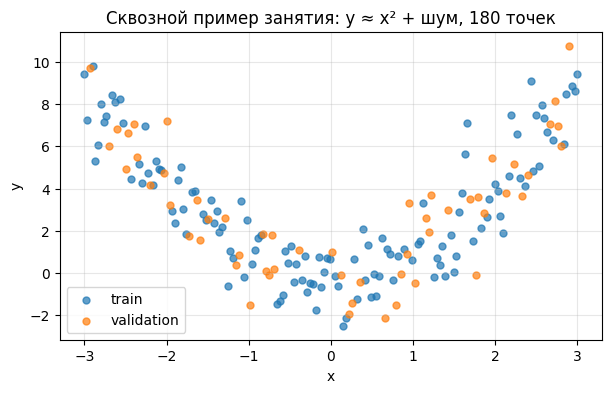

Train: 126 | validation: 54


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)
X = np.linspace(-3, 3, 180).reshape(-1, 1)
y = X[:, 0] ** 2 + rng.normal(0, 1.5, len(X))

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

plt.figure(figsize=(7, 4))
plt.scatter(X_tr, y_tr, s=25, alpha=0.7, label='train')
plt.scatter(X_val, y_val, s=25, alpha=0.7, label='validation')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Сквозной пример занятия: y ≈ x² + шум, 180 точек')
plt.grid(alpha=0.3); plt.legend(); plt.show()
print('Train:', len(X_tr), '| validation:', len(X_val))

## 1. Ошибка на train и на новых данных

**Train error** — ошибка на данных, на которых модель **обучалась** (вызывался `fit`).

**Validation error** — ошибка на данных, которые модель **не видела** при обучении коэффициентов.

Если train-ошибка низкая, а validation высокая, модель, скорее всего, **запомнила** train, а не выучила закономерность.

На сквозном примере выше: train error — MSE на синих точках (по ним модель училась), validation error — MSE на оранжевых, которые модель при обучении не видела.

## 2. Три состояния модели

| Состояние | Train error | Validation error | Интуиция |
|-----------|-------------|------------------|----------|
| **Недообучение** (underfitting) | высокая | высокая | модель слишком проста |
| **Хорошее обобщение** | умеренная | близка к train | разумная сложность |
| **Переобучение** (overfitting) | очень низкая | заметно выше train | модель запомнила шум |

**На сквозном примере** (MSE, код ниже):

| степень полинома | train error | validation error | диагноз |
|------------------|-------------|------------------|---------|
| 1 | 9.49 | 9.23 | недообучение: прямая не описывает $y \approx x^2$ |
| 2 | 1.62 | 1.80 | хорошее обобщение |
| 15 | 1.51 | 2.07 | переобучение: кривая «обвивает» шум train |

**Важно:** сравнивайте train и validation **на одном протоколе** (одинаковый split, одна метрика). Низкая train-ошибка сама по себе ничего не гарантирует.

In [53]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

grid = np.linspace(-3, 3, 300).reshape(-1, 1)
plt.figure(figsize=(8, 4.5))
plt.scatter(X_tr, y_tr, s=20, alpha=0.5, label='train')
for degree, color in [(1, 'tab:red'), (2, 'tab:green'), (15, 'tab:purple')]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    m = LinearRegression().fit(poly.fit_transform(X_tr), y_tr)
    mse_tr = mean_squared_error(y_tr, m.predict(poly.transform(X_tr)))
    mse_val = mean_squared_error(y_val, m.predict(poly.transform(X_val)))
    plt.plot(grid, m.predict(poly.transform(grid)), color=color, linewidth=2,
             label=f'степень {degree}: train {mse_tr:.2f}, val {mse_val:.2f}')
plt.ylim(-4, 12)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Три состояния модели на сквозном примере')
plt.grid(alpha=0.3); plt.legend(); plt.show()

## 3. Откуда берётся переобучение

Модель учит и **закономерность**, и **случайный шум** в train. Риск переобучения растёт, если:

- **мало данных**, а модель гибкая;
- **много признаков** или высокая степень полинома;
- долго **перебирали** варианты по одной и той же validation-выборке;
- есть **утечка данных** — информация из validation так или иначе попала в обучение.

Регуляризация и ограничение сложности снижают риск, но **не заменяют** честную проверку на отложенных данных.

## 4. Смещение и разброс *

Почему одна модель недообучается, а другая переобучается? У ошибки на новых данных есть **два разных источника**.

**Смещение (bias)** — модель **в принципе не способна** описать закономерность. Прямая (степень 1) не умеет изгибаться, поэтому на нашей параболе она промахивается **всегда и одинаково**: занижает по краям и завышает в центре — какой бы train ей ни достался. Это и есть недообучение.

**Разброс (variance)** — модель **слишком чутко реагирует на конкретный train**. Полином 15-й степени подстраивается под случайный шум: дайте ему другие точки — и кривая изогнётся совсем иначе. Предсказания «прыгают» от выборки к выборке. Это и есть переобучение.

Проверим на сквозном примере: обучим обе модели **пять раз** на разных случайных подвыборках train и нарисуем все кривые.

- **Степень 1** (слева): пять прямых почти совпадают — разброс низкий. Но все они одинаково далеки от параболы — смещение высокое.
- **Степень 15** (справа): кривые гуляют от запуска к запуску — разброс высокий, хотя в среднем они повторяют форму параболы — смещение низкое.

С ростом сложности смещение **падает**, а разброс **растёт**. Хорошая модель — компромисс между ними; найти его помогает validation.

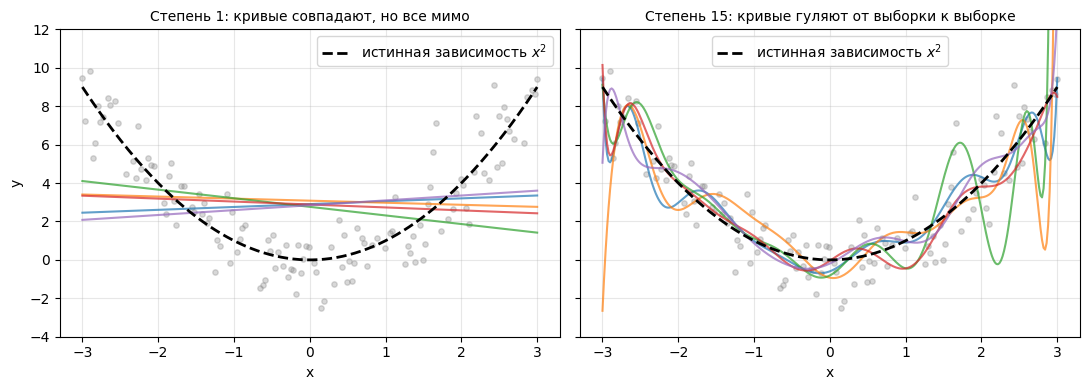

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, degree, title in [
    (axes[0], 1, 'Степень 1: кривые совпадают, но все мимо'),
    (axes[1], 15, 'Степень 15: кривые гуляют от выборки к выборке'),
]:
    ax.scatter(X_tr, y_tr, s=15, alpha=0.3, color='gray')
    for seed in range(5):
        idx = np.random.default_rng(seed).choice(len(X_tr), 40, replace=False)
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        m = LinearRegression().fit(poly.fit_transform(X_tr[idx]), y_tr[idx])
        ax.plot(grid, m.predict(poly.transform(grid)), alpha=0.7)
    ax.plot(grid, grid[:, 0] ** 2, 'k--', linewidth=2, label='истинная зависимость $x^2$')
    ax.set_ylim(-4, 12); ax.set_title(title, fontsize=10)
    ax.set_xlabel('x'); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('y')
plt.tight_layout(); plt.show()

## 5. Параметры и гиперпараметры

**Параметры** — числа, которые модель **учит из train** при вызове `fit`. Пример: коэффициенты `LinearRegression`.

**Гиперпараметры** — настройки, которые задаёт **исследователь до** `fit`. Пример: степень полинома в `PolynomialFeatures(degree=...)`, сила регуляризации.


**Правило:** параметры учат на **train**; гиперпараметры выбирают по **validation**. **Test** для подбора не используют.

## 6. Train, validation и test

Роли трёх выборок вы уже знаете: train — обучение параметров (`fit`), validation — сравнение идей и подбор настроек, test — финальная проверка **один раз**.

Для сквозного примера split train/validation (70 % / 30 %) мы сделали в самом начале занятия — именно на нём считались все ошибки выше.

Главная опасность — нарушение протокола: если посмотреть test, изменить степень полинома и снова посмотреть test, вы фактически **обучаетесь на test**, и его оценка становится оптимистичной.

В этом занятии мы работаем с train + validation; test появится в финальном протоколе в конце.

## 7. Перебор гиперпараметров и «переобучение на validation»

Если проверить **сотни** комбинаций на **одной** validation-выборке, случайно найдётся удачная — исследователь подстраивается под validation так же, как модель под train.

**Что делать:**
- ограничить хаотичный перебор;
- проверять результат на **нескольких** разбиениях, а не на одном;
- сохранить **независимый test** для финала.

Одна validation-оценка также зависит от **случайного** состава объектов. Если повторить split несколько раз и сравнить результаты, видно, насколько вывод **устойчив** — а не основан на одной удачной или неудачной выборке.

## 8. Validation curve

**Validation curve** — название **типа графика**: по оси X — значение гиперпараметра, по оси Y — ошибка модели. Это не «кривая только по validation-данным» — на графике обычно **две** линии, и их сравнивают.

На сквозном примере:
- **MSE на train** — ошибка на синих точках (по ним модель училась);
- **MSE на val-выборке** — ошибка на оранжевых точках из начала занятия (30 %; при `fit` модель их не видела).

**Как читать** (степень полинома слева направо):
- **слева** — недообучение: обе ошибки высоки;
- **середина** — MSE на val-выборке минимальна → разумная сложность;
- **справа** — переобучение: train MSE падает, MSE на val-выборке **растёт**.

Гиперпараметр выбирают по **минимуму MSE на val-выборке**, не по train.

In [55]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

degrees = range(1, 16)
train_scores, val_scores = [], []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr_poly = poly.fit_transform(X_tr)
    Xval_poly = poly.transform(X_val)
    m = LinearRegression().fit(Xtr_poly, y_tr)
    train_scores.append(mean_squared_error(y_tr, m.predict(Xtr_poly)))
    val_scores.append(mean_squared_error(y_val, m.predict(Xval_poly)))

plt.plot(degrees, train_scores, label='MSE на train')
plt.plot(degrees, val_scores, label='MSE на val-выборке')
plt.xlabel('Степень полинома')
plt.ylabel('MSE, меньше — лучше')
plt.title('Validation curve: MSE vs степень полинома')
plt.grid(alpha=0.3); plt.legend(); plt.show()


## 9. Learning curve

В **validation curve** мы меняли **сложность** модели при фиксированном train. **Learning curve** отвечает на другой вопрос: *поможет ли больше обучающих данных?*

**Идея эксперимента:** гиперпараметры фиксируем (полином 5-й степени), val-выборку **не трогаем** — те же оранжевые точки из начала занятия. Меняем только то, **сколько синих точек train** отдаём модели: сначала 25 %, потом 40 %, … до 100 %. Каждый раз заново обучаем модель и считаем две ошибки.

Так мы моделируем ситуацию «у нас пока мало данных, а если бы их стало больше — качество выросло бы?» — без сбора новых объектов.

**Три типичных картины:**
1. Обе линии плохи и близки → модель, вероятно, **слишком проста** (нужна сложнее модель или признаки).
2. Train хорош, val-выборка заметно хуже → **переобучение**; больше данных может помочь.
3. Линии почти сошлись на низком уровне → добавление данных в этом диапазоне **мало поможет**; нужна другая модель или признаки.

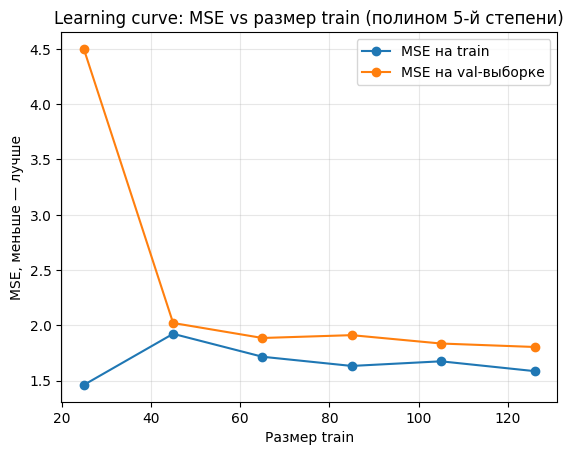

In [59]:
from sklearn.metrics import mean_squared_error

# val-выборка фиксирована; берём растущую долю train: 20 % → 100 %
fractions = np.linspace(0.2, 1.0, 6)
train_mse, val_mse, sizes = [], [], []
for frac in fractions:
    n = max(int(len(X_tr) * frac), 10)
    poly = PolynomialFeatures(degree=5, include_bias=False)
    m = LinearRegression().fit(poly.fit_transform(X_tr[:n]), y_tr[:n])
    train_mse.append(mean_squared_error(y_tr[:n], m.predict(poly.transform(X_tr[:n]))))
    val_mse.append(mean_squared_error(y_val, m.predict(poly.transform(X_val))))
    sizes.append(n)

plt.plot(sizes, train_mse, marker='o', label='MSE на train')
plt.plot(sizes, val_mse, marker='o', label='MSE на val-выборке')
plt.xlabel('Размер train'); plt.ylabel('MSE, меньше — лучше')
plt.title('Learning curve: MSE vs размер train (полином 5-й степени)')
plt.grid(alpha=0.3); plt.legend(); plt.show()


## 10. K-fold cross-validation

**K-fold CV:** данные делят на $k$ **fold** (частей). Модель обучают $k$ раз:
- в каждом запуске **один** fold — validation, остальные $k-1$ — train;
- метрики усредняют по $k$ запускам.

При **5-fold** и одном варианте гиперпараметров выполняется **5 обучений** (`fit`).

**Плюсы:** оценка устойчивее одного split. **Минусы:** дороже по времени.

В `cross_validate` поле `test_score` — метрика на validation-fold (не путать с финальным test).

In [57]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

cv = KFold(n_splits=5, shuffle=True, random_state=42)
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('model', LinearRegression()),
])
result = cross_validate(
    pipe, X, y, cv=cv,
    scoring='neg_mean_squared_error', return_train_score=True,
)
print('Validation scores (neg MSE):', result['test_score'].round(3))
print('Средняя MSE:', round(-result['test_score'].mean(), 3))
print('Разброс по fold (std neg MSE):', round(result['test_score'].std(), 3))


Validation scores (neg MSE): [-2.186 -1.48  -2.434 -1.365 -1.337]
Средняя MSE: 1.76
Разброс по fold (std neg MSE): 0.458


## 11. Стратификация, группы и время

Схема разбиения должна отражать реальную структуру данных: связанные объекты не должны оказываться по разные стороны split. Готовые инструменты sklearn:

| Ситуация | Инструмент | Зачем |
|----------|------------|-------|
| Классификация, редкий класс | `StratifiedKFold` | в каждом fold примерно те же доли классов |
| Несколько записей на одного пациента / пользователя | `GroupKFold` | все записи одной группы — только в train **или** только в validation |
| Прогноз будущего по прошлому | `TimeSeriesSplit` | train — прошлое, validation — будущее |

**Схемы ниже — не графики качества.** Каждая **строка** — один объект таблицы (в фиксированном порядке), каждый **столбец** — один запуск CV (один fold в роли validation). Цвет показывает роль объекта в этом запуске: синий — train, оранжевый — validation, серый — объект ещё не участвует (только для временного split).

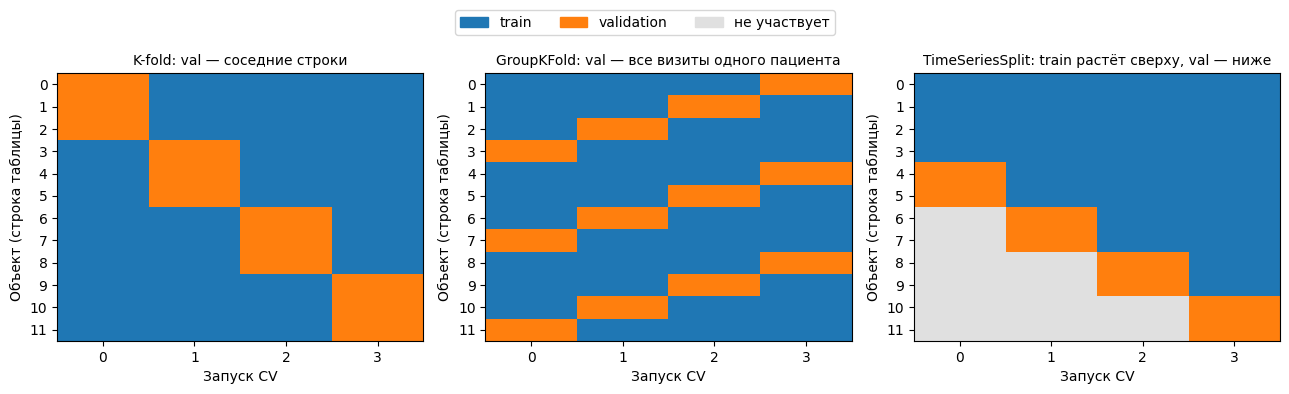

In [58]:
from sklearn.model_selection import KFold, GroupKFold, TimeSeriesSplit
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

n = 12
X_dummy = np.arange(n).reshape(-1, 1)
# 4 «пациента», по 3 визита; объекты в таблице упорядочены по времени, не по пациенту
groups = np.array([0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3])

ROLE_TRAIN, ROLE_VAL, ROLE_SKIP = 0, 1, 2
cmap = ListedColormap(['#1f77b4', '#ff7f0e', '#e0e0e0'])
legend_handles = [
    Patch(color='#1f77b4', label='train'),
    Patch(color='#ff7f0e', label='validation'),
    Patch(color='#e0e0e0', label='не участвует'),
]

def splits_to_matrix(splitter, groups=None):
    rows = []
    kwargs = {'groups': groups} if groups is not None else {}
    for tr, va in splitter.split(X_dummy, **kwargs):
        row = np.full(n, ROLE_SKIP)
        row[tr] = ROLE_TRAIN
        row[va] = ROLE_VAL
        rows.append(row)
    return np.array(rows)

kfold_mat = splits_to_matrix(KFold(n_splits=4, shuffle=False))
group_mat = splits_to_matrix(GroupKFold(n_splits=4), groups=groups)
ts_mat = splits_to_matrix(TimeSeriesSplit(n_splits=4))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
titles = [
    'K-fold: val — соседние строки',
    'GroupKFold: val — все визиты одного пациента',
    'TimeSeriesSplit: train растёт сверху, val — ниже',
]
for ax, mat, title in zip(axes, [kfold_mat, group_mat, ts_mat], titles):
    # строки — объекты, столбцы — запуски CV
    ax.imshow(mat.T, aspect='auto', cmap=cmap, vmin=0, vmax=2)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Объект (строка таблицы)')
    ax.set_xlabel('Запуск CV')
    ax.set_xticks(range(mat.shape[0]))
    ax.set_xticklabels([f'{i}' for i in range(mat.shape[0])])
    ax.set_yticks(range(n))
fig.legend(handles=legend_handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.1))
plt.tight_layout(); plt.show()


## 12. Предобработка внутри каждого fold

Правило вы уже знаете: `fit` преобразований — только на train. Новое при кросс-валидации: train меняется **от fold к fold**, поэтому и предобработку обучают заново **на train-части каждого fold**.

**Безопасная последовательность внутри одного fold:**

`fit preprocessing на fold-train` → `transform` fold-train и fold-validation → `fit` модель → `score` на fold-validation.

**Пример утечки:** `poly.fit_transform(X_вся_таблица)` **до** split — validation повлияла на выбор признаков. Правильно: `fit` только на train, `transform` на train и val.

## 13. Утечки в CV и grid search

**Типичные утечки:**
- масштабирование или **заполнение пропусков** на **всей** таблице до CV;
- отбор признаков по корреляции с целью на **всей** таблице;
- подгонка степени полинома по **test**.

**Как не ошибиться:** у каждого шага спросите — *считает ли он статистику по данным?* Масштаб (`StandardScaler`), медиана для пропусков, `PolynomialFeatures` — да: их `fit` вызывают **только на train** (в CV — на train-части fold). Validation и test получают уже готовое преобразование через `transform` / `predict`, без повторного `fit`.

Пример утечки: `scaler.fit(X_вся_таблица)` до split — в масштаб «подсмотрела» validation. Правильно: `scaler.fit(X_train)` → `scaler.transform(X_val)`.

**Grid search** (`GridSearchCV`) перебирает сетку гиперпараметров и оценивает каждый вариант CV. Чем больше вариантов, тем выше риск случайно «попасть» в удачный fold. Поэтому **test** остаётся отдельно.

## 14. Вложенная валидация *

**Вложенная CV (nested CV):**
- **внутренний** цикл — подбор гиперпараметров;
- **внешний** цикл — оценка всего процесса выбора.

Защищает от оптимистичной оценки при большом grid search. Метод дорогой; в учебном проекте достаточно понимать различие **настройки** (validation/CV) и **независимой оценки** (test).

## 15. Воспроизводимость: seeds и версии артефактов

Валидация честна, только если её можно **повторить и получить тот же результат** — иначе невозможно понять, улучшила ли модель ваша идея или просто «повезло» с разбиением.

**Случайность в наших экспериментах** появляется в трёх местах:
- генерация данных — `np.random.default_rng(42)` в сквозном примере;
- split — `train_test_split(..., random_state=42)`;
- перемешивание в CV — `KFold(..., shuffle=True, random_state=42)`.

**Seed (зерно)** — число, которое фиксирует генератор случайных чисел: с одним и тем же seed «случайные» результаты повторяются точь-в-точь. Поэтому во всём занятии стоит `42`: перезапустите блокнот — получите те же MSE.

**Правила:**
- задавайте `random_state` **везде**, где есть случайность (split, CV, инициализация модели);
- сравнивая две идеи, используйте **одинаковый** seed и одинаковый split — иначе разница может быть случайной;
- проверяя **устойчивость** вывода, наоборот, меняйте seed осознанно и смотрите на разброс результатов.

**Контроль версий артефактов.** Чтобы результат можно было воспроизвести через месяц, фиксируют не только seed, но и всё, из чего он получен:

| Артефакт | Как фиксировать |
|----------|-----------------|
| Данные | версия/дата выгрузки файла, не «перезаписанная последняя» |
| Код | коммит в git, а не «код в блокноте кто-то поменял» |
| Окружение | версии библиотек (`requirements.txt`): sklearn может менять поведение между версиями |
| Модель и метрики | сохранённая модель + протокол: seed, split, гиперпараметры, результаты |

**Мини-правило:** отчёт о качестве модели без seed, версии данных и версии кода невозможно ни проверить, ни повторить.

## 16. Финальный протокол

1. **Отделить test** подходящим способом.
2. На train+validation сравнивать идеи **одним** CV-протоколом.
3. Выбрать модель и гиперпараметры по validation/CV.
4. **Переобучить** выбранный процесс на всех train+validation данных.
5. **Один раз** оценить на test.
6. Сообщить среднее, разброс по fold, seed и версии артефактов, ограничения данных.

На сквозном примере протокол выглядит так: отложить test → выбрать степень полинома по validation curve / CV (получилась степень 2) → переобучить полином степени 2 на всех train+validation → один раз посчитать MSE на test.

> **Главная мысль.** Валидация проверяет не только алгоритм, но и **честность** всего способа получения модели.